### 결정 트리 모델의 시각화 (Decision Tree Visualization)

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# DecisionTreeClassifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data,iris_data.target,test_size=0.2,random_state=11)

dt_clf.fit(X_train,y_train)


DecisionTreeClassifier(random_state=156)

In [20]:
from sklearn.tree import export_graphviz

export_graphviz(dt_clf,out_file='tree.dot', class_names=iris_data.target_names, feature_names=iris_data.feature_names, impurity=True, filled=True)

In [5]:
iris_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

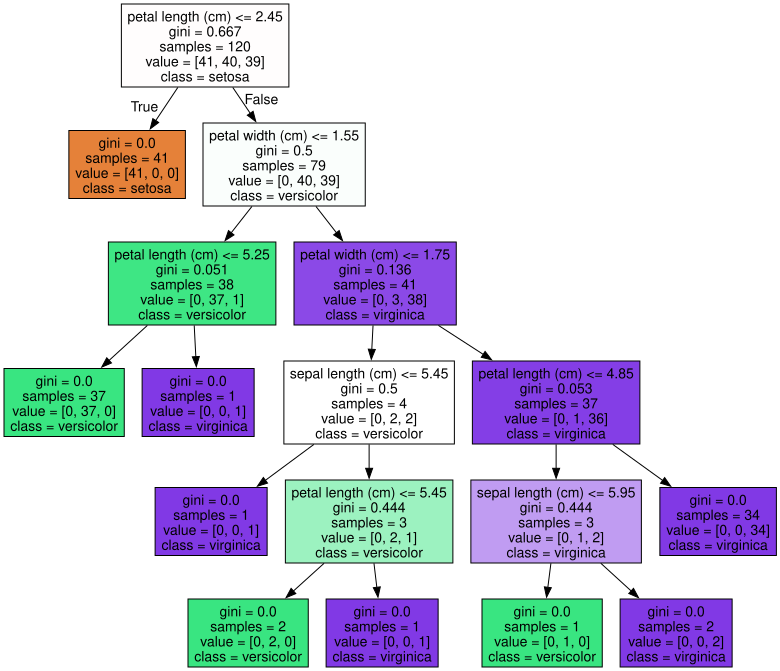

In [21]:
import graphviz

# 위에서 생성한 tree.dot 파일을 Graphviz 읽어서 Jupyter Notebook 상에서 시각화
with open("tree.dot") as f :
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [22]:
dt_clf.feature_importances_

array([0.02500521, 0.        , 0.55490281, 0.42009198])

In [26]:
iris_data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Feature import: 
[0.025 0.    0.555 0.42 ]
sepal length (cm), 0.025
sepal width (cm), 0.000
petal length (cm), 0.555
petal width (cm), 0.420


<Axes: >

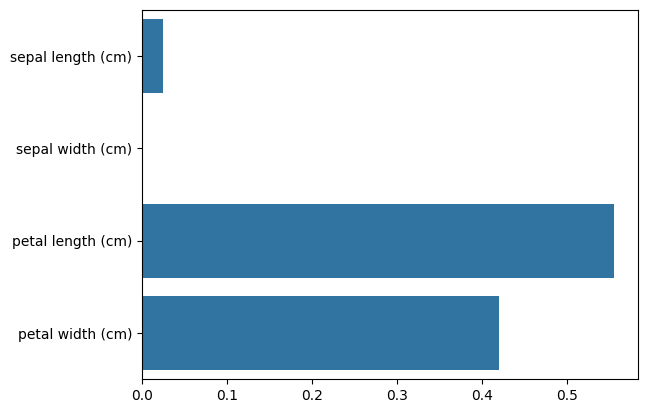

In [27]:
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print('Feature import: \n{0}'.format(np.round(dt_clf.feature_importances_,3)))

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_) :
    print('{0}, {1:.3f}'.format(name, value))

sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

### 결정 트리(Desision TREE) 과적합 (Overfitting)

In [31]:
X_features.shape

(100, 2)

In [35]:
np.unique(y_labels)

array([0, 1, 2])

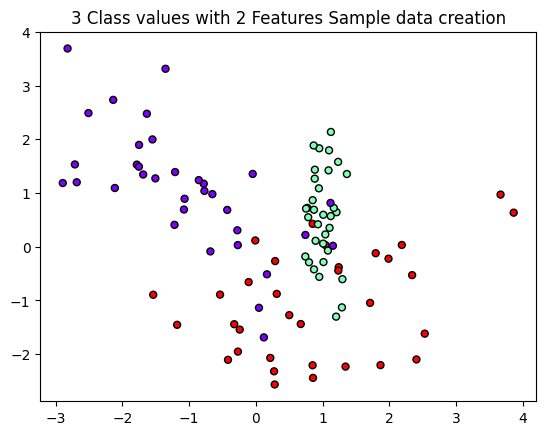

In [30]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title('3 Class values with 2 Features Sample data creation')

# 2차원 시각화를 위해서 feature는 2개, 결정값 클래스는 3가지 유형의 classification 샘플 데이터 생성
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                           n_classes=3, n_clusters_per_class=1, random_state=0)

plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels, s=25, cmap='rainbow', edgecolors='k')
